# 04. Stress testing and model monitoring

**Purpose.** Two questions a lender's risk team asks once a model is live:

1. **What if the economy turns?** How much would expected losses on the approved book rise, which industries would hurt most, and how many deals that approve today would not?
2. **Is the model still seeing the kind of applications it was trained on?** If the mix of applications drifts, the model's numbers can quietly stop being trustworthy.

Downturn severity and industry sensitivity are **measured from real SBA loan vintages** (`src/metro_deal_desk/cycle_calibration.py`, saved to `data/calibration/cycle_sensitivity.json`). Loss given default by asset type is a labelled assumption.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from metro_deal_desk import stress, monitoring

pd.set_option("display.float_format", "{:,.2f}".format)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "axes.axisbelow": True})
BAR, HI = "#3b6ea5", "#c8553d"
cal = stress.load_calibration()
queue = pd.read_csv("../data/scored/scored_queue.csv")
approved = queue[queue["decision"] == "Approve"]
print(f"Approved book: {len(approved):,} loans, ${approved['loan_amount'].sum():,.0f} exposure")

Approved book: 990 loans, $60,188,300 exposure


## 1. Scenarios tied to real history

Each scenario is an SBA loan vintage. Its multiplier is that vintage's odds of default compared with the 2000 to 2010 average, after controlling for industry, loan size and business age (notebook 01). The synthetic book is calibrated to the through-the-cycle average, so **baseline = 1.0**.

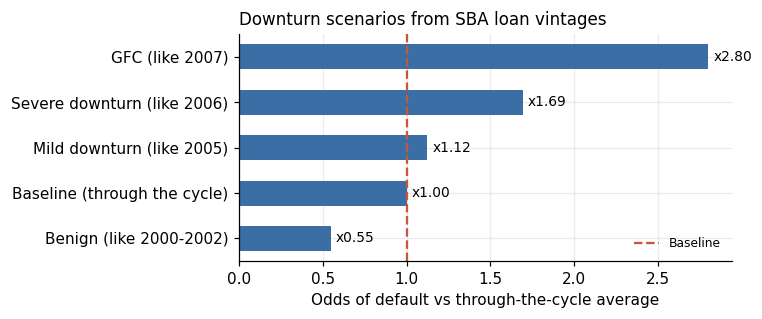

,label,odds_multiplier,based_on_vintages
key,,,
benign,Benign (like 2000-2002),0.55,"[2000, 2001, 2002]"
baseline,Baseline (through the cycle),1.00,2000-2010 average
mild,Mild downturn (like 2005),1.12,[2005]
severe,Severe downturn (like 2006),1.69,[2006]
gfc,GFC (like 2007),2.80,[2007]


In [2]:
sc = pd.DataFrame(stress.scenarios()).set_index("key")
fig, ax = plt.subplots(figsize=(7, 3))
ax.barh(sc["label"], sc["odds_multiplier"], color=BAR, height=0.55)
ax.axvline(1, color=HI, ls="--", lw=1.5, label="Baseline")
for i, v in enumerate(sc["odds_multiplier"]):
    ax.text(v + 0.03, i, f"x{v:.2f}", va="center", fontsize=9)
ax.set_xlabel("Odds of default vs through-the-cycle average"); ax.legend(frameon=False, fontsize=8)
ax.set_title("Downturn scenarios from SBA loan vintages", loc="left", fontsize=11)
plt.tight_layout(); plt.show()
sc[["label", "odds_multiplier", "based_on_vintages"]]

## 2. Which industries suffer most in a downturn?

Crisis vintages (2006 to 2008) compared with calm ones (2000 to 2003), relative to all industries. **1.0 = hit as hard as the average industry.** Industries with few loans are pulled toward 1.0 so a small sample cannot produce an extreme number (credibility weighting).

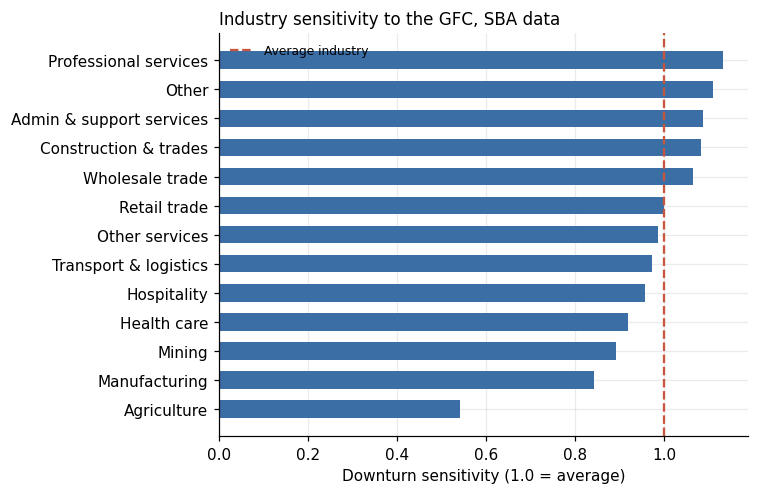

,sensitivity,crisis_vs_calm_odds_ratio,sba_loans
Agriculture,0.54,1.09,1953
Manufacturing,0.84,2.93,16290
Mining,0.89,1.83,504
Health care,0.92,3.28,12361
Hospitality,0.96,3.48,25010
Transport & logistics,0.97,3.54,7285
Other services,0.99,3.63,19143
Retail trade,1.00,3.70,34188
Wholesale trade,1.06,4.11,9335
Construction & trades,1.08,4.19,12638


In [3]:
ind = pd.DataFrame(cal["industry_sensitivity"]).T.astype({"sba_loans": int}).sort_values("sensitivity")
fig, ax = plt.subplots(figsize=(7, 4.6))
ax.barh(ind.index, ind["sensitivity"], color=BAR, height=0.6)
ax.axvline(1, color=HI, ls="--", lw=1.5, label="Average industry")
ax.set_xlabel("Downturn sensitivity (1.0 = average)"); ax.legend(frameon=False, fontsize=8)
ax.set_title("Industry sensitivity to the GFC, SBA data", loc="left", fontsize=11)
plt.tight_layout(); plt.show()
ind

Agriculture barely moved in the GFC, while professional services, construction and admin services were hit harder than average: their demand falls quickly when businesses cut back. Health care, often assumed to be defensive, was close to average in this data.

## 3. Stress the approved book

Expected loss = probability of default x loss given default x exposure. In a downturn both parts rise: more loans default, and repossessed assets sell for less (downturn LGD, up to +10 points at GFC severity).

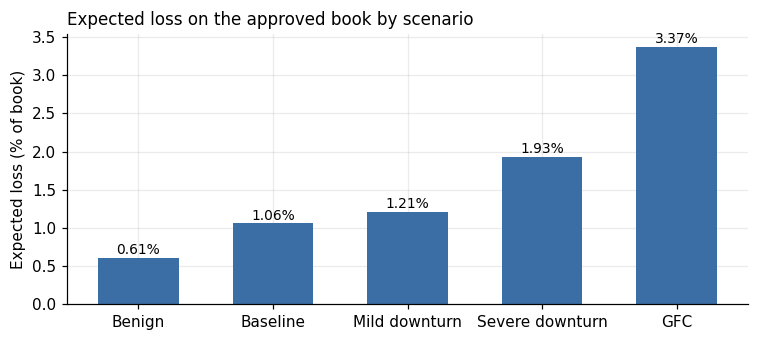

,avg PD %,expected defaults,expected loss $,expected loss % of book,approvals that would no longer auto-approve %
scenario,,,,,
Benign (like 2000-2002),1.50,14.87,"365,754.91",0.61,0.00
Baseline (through the cycle),2.65,26.28,"636,569.00",1.06,0.00
Mild downturn (like 2005),2.96,29.34,"728,685.74",1.21,7.68
Severe downturn (like 2006),4.36,43.15,"1,163,366.26",1.93,33.54
GFC (like 2007),6.94,68.71,"2,030,732.65",3.37,72.22


In [4]:
rows = []
for key in ["benign", "baseline", "mild", "severe", "gfc"]:
    r = stress.run(approved, key)
    rows.append({"scenario": r["label"], "avg PD %": r["stressed"]["avg_pd_pct"],
                 "expected defaults": r["stressed"]["expected_defaults"],
                 "expected loss $": r["stressed"]["expected_loss"],
                 "expected loss % of book": r["stressed"]["expected_loss_pct"],
                 "approvals that would no longer auto-approve %": r["would_no_longer_auto_approve_pct"]})
table = pd.DataFrame(rows).set_index("scenario")

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.bar(range(len(table)), table["expected loss % of book"], color=BAR, width=0.6)
ax.set_xticks(range(len(table)), [s.split(" (")[0] for s in table.index])
for i, v in enumerate(table["expected loss % of book"]):
    ax.text(i, v + 0.05, f"{v:.2f}%", ha="center", fontsize=9)
ax.set_ylabel("Expected loss (% of book)")
ax.set_title("Expected loss on the approved book by scenario", loc="left", fontsize=11)
plt.tight_layout(); plt.show()
table

### GFC scenario by industry

In [5]:
gfc = stress.run(approved, "gfc")
pd.DataFrame(gfc["by_industry"]).set_index("industry")[
    ["loans", "exposure", "avg_pd_base_pct", "avg_pd_stressed_pct", "expected_loss_stressed", "loss_multiple"]]

,loans,exposure,avg_pd_base_pct,avg_pd_stressed_pct,expected_loss_stressed,loss_multiple
industry,,,,,,
Construction & trades,193,"11,563,100.00",2.84,8.11,"438,755.21",3.62
Transport & logistics,142,"11,498,500.00",2.41,6.24,"341,286.02",3.25
Agriculture,82,"7,697,900.00",2.82,4.79,"173,353.57",2.17
Professional services,112,"4,933,000.00",2.28,6.88,"164,094.40",3.77
Wholesale trade,54,"4,084,400.00",2.76,7.77,"155,929.49",3.52
Retail trade,75,"3,746,400.00",2.93,7.75,"153,866.38",3.23
Manufacturing,74,"4,236,700.00",2.36,5.39,"135,953.75",2.78
Health care,65,"2,713,600.00",2.82,6.91,"110,834.80",2.94
Hospitality,57,"2,697,900.00",2.84,7.20,"100,003.61",3.12


**Reading it.** Losses on the approved book roughly triple in a GFC-like downturn, and about seven in ten deals approved automatically today would need a credit officer's review under the same thresholds. A lender might respond by tightening thresholds or pricing for cyclical industries before a downturn, or by holding more capital against them.

## 4. Monitoring: is the model still seeing familiar applications?

Population Stability Index (PSI) compares the live queue with the training data, feature by feature. Under 0.10 stable, 0.10 to 0.25 watch, above 0.25 investigate.

In [6]:
live = monitoring.drift_report(queue)
print("Overall:", live["overall_status"])
pd.DataFrame(live["features"])[["label", "psi", "status"]].assign(psi=lambda d: d["psi"].map("{:.4f}".format))

Overall: Stable


,label,psi,status
0,Loan amount,0.0016,Stable
1,Loan term,0.0009,Stable
2,Model score (PD),0.0049,Stable
3,Industry mix,0.0115,Stable
4,Asset mix,0.0011,Stable


The live queue comes from the same process as the training data, so it should be stable. To check the monitor actually works, apply three hypothetical shifts and confirm each one is caught on the right feature.

In [7]:
rows = []
for name, note in monitoring.SIMULATIONS.items():
    rep = monitoring.drift_report(monitoring.simulate(queue, name))
    worst = max(rep["features"], key=lambda f: f["psi"])
    rows.append({"simulation": note, "overall": rep["overall_status"],
                 "most shifted feature": worst["label"], "psi": worst["psi"]})
pd.DataFrame(rows).assign(psi=lambda d: d["psi"].map("{:.3f}".format))

,simulation,overall,most shifted feature,psi
0,Construction & trades rises to 45% of applicat...,Shift,Industry mix,0.270
1,Loan amounts 40% larger across the board (for ...,Watch,Loan amount,0.247
2,Model scores 30% higher across the board (for ...,Shift,Model score (PD),0.253


## Limitations

- Scenario severities come from US small business loans in the 2000s; an Australian downturn could look different.
- The stress applies one multiplier per industry. A real stress test would also model unemployment, interest rates and used-vehicle prices.
- LGD values and the downturn LGD uplift are assumptions, not measurements.
- PSI shows that inputs have changed, not whether the model has become wrong; that needs actual outcomes, which arrive months later.